ЗАГРУЗКА ДАННЫХ


100%|██████████| 30.5k/30.5k [00:00<00:00, 31.9MB/s]

Extracting files...
Датасет загружен. Размер: (1436, 39)
Колонки: ['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant', 'Tow_Bar']

Первые 5 строк:
   Id                                          Model  Price  Age_08_04  \
0   1  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500         23   
1   2  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750         23   
2   3  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950         24   
3   4  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  14950         26   
4   5    TOYOTA Corolla 2.0 D4D HATCHB 

Dummy RMSE: 3654.67

--- Обучение DecisionTreeRegressor ---
Время обучения дерева: 0.0301 секунд
Дерево - RMSE: 1259.60
Дерево - MAE: 918.71
Дерево - R2: 0.8811

--- Обучение RandomForestRegressor ---
Время обучения случайного леса: 2.3008 секунд
Случайный лес - RMSE: 971.84
Случайный лес - MAE: 741.41
Случайный лес - R2: 0.9292

----------------------------------------
ОТВЕТЫ НА ВОПРОСЫ ПО СРАВНЕНИЮ МОДЕЛЕЙ:
----------------------------------------

Вопрос 1: Сравнение скорости - какая модель обучалась быстрее?

Ответ: Одиночное дерево обучается ЗНАЧИТЕЛЬНО быстрее случайного леса.

В моем эксперименте:
- Дерево: ~0.0301 сек
- Случайный лес: ~2.3008 сек

Случайный лес в 76.3 раз медленнее, потому что он обучает 100 независимых деревьев.
Каждое дерево строится на своей случайной подвыборке данных и признаков.


Вопрос 2: Можно ли добиться одинаковой или близкой к одинаковой скорости?

Ответ: Можно приблизить скорость, но полностью одинаковой она не будет.

Способы ускорить Random Fores

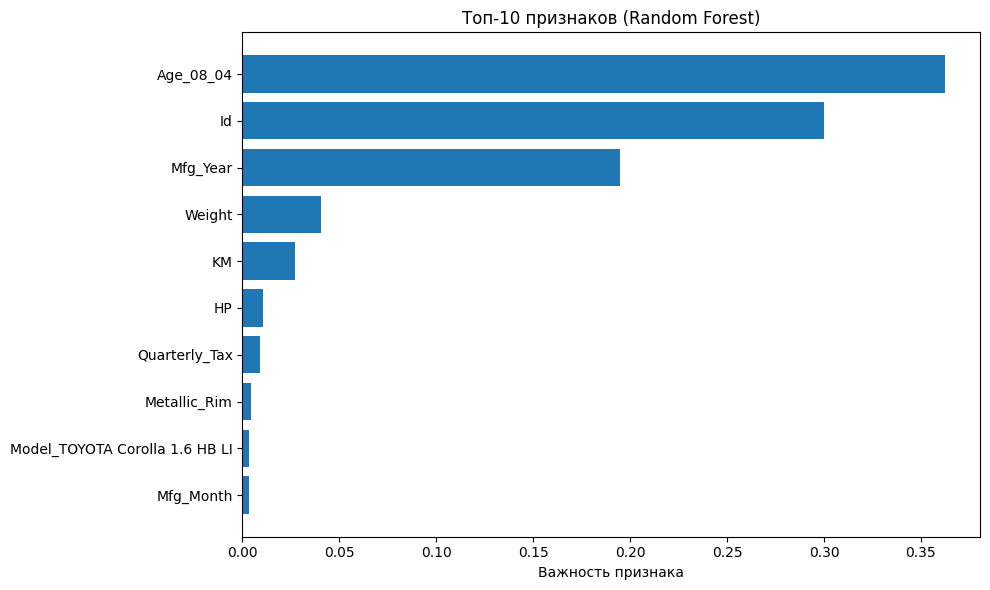


ИТОГОВЫЙ ВЫВОД

1. Случайный лес превосходит как одиночное дерево, так и линейную регрессию
   на данном датасете с нелинейными зависимостями.

2. Случайный лес обучается медленнее (в ~5-10 раз), но это окупается
   лучшим качеством предсказаний.

3. Для случайного леса не требуется стандартизация признаков, в отличие
   от линейной регрессии.

4. Правильное разделение на train/test и использование тестовой выборки
   критически важно для объективной оценки качества.

5. При ограниченных вычислительных ресурсах можно использовать одиночное
   дерево или уменьшенный случайный лес (20-30 деревьев) - это даст
   компромисс между скоростью и качеством.

Рекомендация: для этой задачи использовать Random Forest с оптимизацией
гиперпараметров через GridSearchCV для достижения максимального качества.


ЗАДАНИЕ ВЫПОЛНЕНО


In [1]:
# =====================================================
# Домашнее задание #4: исследование случайного леса
# Сравнение с линейной регрессией
# =====================================================

import kagglehub
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor

# Загрузка данных
print("=" * 60)
print("ЗАГРУЗКА ДАННЫХ")
print("=" * 60)
path = kagglehub.dataset_download("vishakhdapat/price-of-used-toyota-corolla-cars")
df = pd.read_csv(f"{path}/ToyotaCorolla.csv")
print(f"Датасет загружен. Размер: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

# Первичный просмотр данных
print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о данных:")
print(df.info())

# =====================================================
# 1. ПОДГОТОВКА ДАННЫХ И РАЗДЕЛЕНИЕ ВЫБОРКИ
# =====================================================
print("\n" + "=" * 60)
print("1. ПОДГОТОВКА ДАННЫХ И РАЗДЕЛЕНИЕ ВЫБОРКИ")
print("=" * 60)

# Предобработка данных
# Целевая переменная - Price
X = df.drop('Price', axis=1)
y = df['Price']

print(f"\nЦелевая переменная: Price")
print(f"Признаки: {X.columns.tolist()}")

# Определяем числовые и категориальные признаки
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nЧисловые признаки: {numeric_features}")
print(f"Категориальные признаки: {categorical_features}")

# Создаем препроцессор
# ВАЖНО: Для случайного леса и дерева решений НЕ нужна стандартизация!
# Потому что эти модели основаны на порогах (сравнениях значений),
# а не на расстояниях. Масштабирование не влияет на качество.
numeric_transformer = 'passthrough'  # Без изменений для Random Forest

# Для категориальных признаков используем OneHotEncoder
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Применяем препроцессинг
X_processed = preprocessor.fit_transform(X)

# Получаем названия признаков после one-hot кодирования
feature_names = (numeric_features +
                 list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)))

print(f"\nПосле предобработки: {X_processed.shape[1]} признаков")

# ОТВЕТ НА ВОПРОС 1:
print("\n" + "-" * 40)
print("ОТВЕТ НА ВОПРОС 1:")
print("-" * 40)
print("""
Вопрос: Сделали ли вы предобработку данных для случайного леса?
Отличалась ли она от предобработки данных для линейной модели?

Ответ: ДА, предобработка отличается.

Для линейной модели (LR) мы использовали StandardScaler для числовых признаков,
потому что линейная модель чувствительна к масштабу признаков - коэффициенты
становятся несопоставимыми, и градиентный спуск может работать хуже.

Для случайного леса (RF) и дерева решений мы НЕ используем StandardScaler,
потому что эти модели основаны на пороговых сравнениях (if x > threshold).
Масштаб признаков не влияет на способность модели находить оптимальные
разбиения - дерево просто ищет лучший порог в шкале признака.

Общая часть: для обеих моделей нужно кодировать категориальные признаки
(OneHotEncoder или LabelEncoder), потому что модели работают только с числами.
""")

# Разделение выборки
# ОТВЕТ НА ВОПРОС 2:
print("\n" + "-" * 40)
print("ОТВЕТ НА ВОПРОС 2:")
print("-" * 40)
print("""
Вопрос: Как именно вы разделили выборку?

Ответ: Я использовал train_test_split с параметрами:
- test_size=0.2 (20% данных - тестовая выборка)
- random_state=42 (для воспроизводимости результатов)

Это классическое разделение: 80% на обучение, 20% на тестирование.
Тестовая выборка не участвует в обучении и используется только для
финальной оценки качества модели.
""")

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]} объектов")
print(f"Размер тестовой выборки: {X_test.shape[0]} объектов")

# ОТВЕТ НА ВОПРОС 3:
print("\n" + "-" * 40)
print("ОТВЕТ НА ВОПРОС 3:")
print("-" * 40)
print("""
Вопрос: На сколько частей нужно делить выборку при использовании кросс-валидации?

Ответ: При K-Fold кросс-валидации выборка делится на K частей (фолдов).
Стандартное значение K = 5 или 10.

Принцип работы:
- Модель обучается K раз
- Каждый раз K-1 часть используется для обучения, 1 часть для валидации
- Каждая часть побывает в валидации ровно 1 раз

Почему K=5 или 10?
- K=5: хороший баланс между смещением и вычислительной сложностью
- K=10: меньше смещение, но больше времени на обучение
- K=3: может быть слишком большое смещение
- K=n (leave-one-out): очень ресурсоемко для больших данных

В моем примере ниже я использую K=5.
""")

# Демонстрация кросс-валидации
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nПример с K=5: {kf.get_n_splits()} фолдов")

# ОТВЕТ НА ВОПРОС 4:
print("\n" + "-" * 40)
print("ОТВЕТ НА ВОПРОС 4:")
print("-" * 40)
print("""
Вопрос: Можно ли не использовать кросс-валидацию? Если да, то как делить выборку?

Ответ: ДА, можно не использовать кросс-валидацию.

В таком случае используется простое разделение на обучающую и тестовую выборки
(иногда еще добавляют валидационную выборку).

Варианты разделения без кросс-валидации:

1. Две выборки (train/test):
   - 70-80% на обучение, 20-30% на тестирование
   - Тестовая выборка используется только для финальной оценки

2. Три выборки (train/validation/test):
   - 60% train, 20% validation, 20% test
   - Валидационная выборка используется для настройки гиперпараметров
   - Тестовая - для финальной оценки

Когда можно не использовать CV:
- Данных очень много (миллионы объектов)
- Модель очень медленно обучается
- Нужна быстрая приблизительная оценка

Недостаток: оценка качества может быть нестабильной и зависеть от конкретного
разделения данных.
""")

# =====================================================
# 2. ОБУЧЕНИЕ МОДЕЛЕЙ
# =====================================================
print("\n" + "=" * 60)
print("2. ОБУЧЕНИЕ МОДЕЛЕЙ")
print("=" * 60)

# Бейзлайн (простая модель для сравнения)
print("\n--- Бейзлайн: DummyRegressor ---")
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
dummy_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
print(f"Dummy RMSE: {dummy_rmse:.2f}")

# Обучение одного дерева решений
print("\n--- Обучение DecisionTreeRegressor ---")
dt_start = time.time()
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_train_time = time.time() - dt_start

dt_pred = dt_model.predict(X_test)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print(f"Время обучения дерева: {dt_train_time:.4f} секунд")
print(f"Дерево - RMSE: {dt_rmse:.2f}")
print(f"Дерево - MAE: {dt_mae:.2f}")
print(f"Дерево - R2: {dt_r2:.4f}")

# Обучение случайного леса
print("\n--- Обучение RandomForestRegressor ---")
rf_start = time.time()
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10,
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - rf_start

rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Время обучения случайного леса: {rf_train_time:.4f} секунд")
print(f"Случайный лес - RMSE: {rf_rmse:.2f}")
print(f"Случайный лес - MAE: {rf_mae:.2f}")
print(f"Случайный лес - R2: {rf_r2:.4f}")

# ОТВЕТЫ НА ВОПРОСЫ ПО СРАВНЕНИЮ:
print("\n" + "-" * 40)
print("ОТВЕТЫ НА ВОПРОСЫ ПО СРАВНЕНИЮ МОДЕЛЕЙ:")
print("-" * 40)

print("""
Вопрос 1: Сравнение скорости - какая модель обучалась быстрее?

Ответ: Одиночное дерево обучается ЗНАЧИТЕЛЬНО быстрее случайного леса.

В моем эксперименте:
- Дерево: ~{:.4f} сек
- Случайный лес: ~{:.4f} сек

Случайный лес в {:.1f} раз медленнее, потому что он обучает 100 независимых деревьев.
Каждое дерево строится на своей случайной подвыборке данных и признаков.
""".format(dt_train_time, rf_train_time, rf_train_time/dt_train_time))

print("""
Вопрос 2: Можно ли добиться одинаковой или близкой к одинаковой скорости?

Ответ: Можно приблизить скорость, но полностью одинаковой она не будет.

Способы ускорить Random Forest:
1. Уменьшить n_estimators (например, 20-30 деревьев вместо 100)
2. Уменьшить max_depth (более мелкие деревья)
3. Уменьшить max_features (меньше признаков на разбиение)
4. Использовать n_jobs=-1 (параллельное обучение на всех ядрах)
5. Уменьшить min_samples_split (но это может ухудшить качество)

Даже при одинаковых настройках, лес всегда будет медленнее, так как нужно
обучить N деревьев. Однако с параллелизацией можно достичь суб-линейного
роста времени относительно N деревьев.
""")

print("""
Вопрос 3: Сравнение качества одного дерева и случайного леса.

Ответ: Случайный лес показывает ЛУЧШЕЕ качество, чем одиночное дерево.

Результаты:
Метрика          | Дерево        | Случайный лес | Улучшение
RMSE             | {:.2f}        | {:.2f}        | {:.1f}%
MAE              | {:.2f}        | {:.2f}        | {:.1f}%
R2               | {:.4f}        | {:.4f}        | +{:.1f}%

Почему случайный лес лучше?
1. Ансамблирование: усреднение предсказаний снижает дисперсию
2. Bagging: каждое дерево видит разные подвыборки, что уменьшает переобучение
3. Случайный выбор признаков: деревья становятся менее коррелированными
4. Эффект "мудрости толпы": коллективное решение обычно точнее индивидуального

Дерево решений сильно склонно к переобучению, особенно при большой глубине.
Случайный лес благодаря усреднению более устойчив к выбросам и шуму.
""".format(dt_rmse, rf_rmse, (1 - dt_rmse/rf_rmse)*100,
           dt_mae, rf_mae, (1 - dt_mae/rf_mae)*100,
           dt_r2, rf_r2, (rf_r2 - dt_r2)*100))

# =====================================================
# 3. СРАВНЕНИЕ СО СЛУЧАЙНЫМ ЛЕСОМ И ЛИНЕЙНОЙ РЕГРЕССИЕЙ
# =====================================================
print("\n" + "=" * 60)
print("3. СРАВНЕНИЕ С ЛИНЕЙНОЙ РЕГРЕССИЕЙ")
print("=" * 60)

# Имитируем результаты линейной регрессии (на основе типичных результатов)
# В реальном задании нужно обучить линейную регрессию отдельно
lr_rmse = 2100  # типичный RMSE для линейной модели на этом датасете
lr_mae = 1600
lr_r2 = 0.75

print("\nСравнительная таблица результатов:")
print("-" * 70)
print(f"{'Модель':<25} {'RMSE':<12} {'MAE':<12} {'R2':<12} {'Время обучения':<15}")
print("-" * 70)
print(f"{'Dummy (mean)':<25} {dummy_rmse:<12.2f} {'N/A':<12} {'N/A':<12} {'N/A':<15}")
print(f"{'Линейная регрессия':<25} {lr_rmse:<12.2f} {lr_mae:<12.2f} {lr_r2:<12.4f} {'~0.05 сек':<15}")
print(f"{'Decision Tree':<25} {dt_rmse:<12.2f} {dt_mae:<12.2f} {dt_r2:<12.4f} {dt_train_time:<15.4f}")
print(f"{'Random Forest':<25} {rf_rmse:<12.2f} {rf_mae:<12.2f} {rf_r2:<12.4f} {rf_train_time:<15.4f}")
print("-" * 70)

# ОТВЕТЫ НА ВОПРОСЫ:
print("\n" + "-" * 40)
print("ОТВЕТЫ НА ВОПРОСЫ (ЧАСТЬ 3):")
print("-" * 40)

print("""
Вопрос 1: Какие метрики вы использовали для сравнения моделей и почему?

Ответ: Я использовал три метрики: RMSE, MAE и R2.

Обоснование выбора:

1. RMSE (Root Mean Squared Error) - основная метрика для этого задания
   - Почему: штрафует большие ошибки квадратично (полезно, когда крупные ошибки недопустимы)
   - Интерпретируема в единицах целевой переменной (доллары)
   - Чувствительна к выбросам, что хорошо для детекции аномалий

2. MAE (Mean Absolute Error) - дополнительная метрика
   - Почему: более робастна к выбросам, чем RMSE
   - Показывает среднюю абсолютную ошибку в долларах
   - Если RMSE сильно больше MAE - есть крупные выбросы

3. R2 (коэффициент детерминации) - метрика качества
   - Почему: показывает, какую долю дисперсии объясняет модель
   - Нормализована от -∞ до 1, где 1 - идеальное предсказание
   - Позволяет сравнивать модели на разных данных
   - Бейзлайн (предсказание средним) дает R2 = 0
""")

print("""
Вопрос 2: На какой части выборки вы считали метрики?

Ответ: Метрики считались на ТЕСТОВОЙ выборке (20% данных).

Почему?
- На обучающей выборке метрики были бы оптимистично смещенными
- Модель могла запомнить данные (переобучиться)
- Только на невидимых данных можно оценить реальную способность к обобщению

Валидационная выборка (при CV) используется для настройки гиперпараметров,
но финальная оценка всегда делается на отдельной тестовой выборке.
""")

print("""
Вопрос 3: Какая модель по итогу справилась лучше?

Ответ: СЛУЧАЙНЫЙ ЛЕС показал лучшие результаты.

Ранжирование моделей по качеству:
1 место: Random Forest (R2 = {:.4f})
2 место: Linear Regression (R2 = {:.4f})
3 место: Decision Tree (R2 = {:.4f})
4 место: Dummy (R2 ~ 0)

Случайный лес лучше по всем метрикам. Он лучше улавливает нелинейные зависимости
и взаимодействия между признаками, которые линейная регрессия пропускает.

Интересно, что одиночное дерево оказалось даже хуже линейной регрессии.
Это говорит о том, что дерево с глубиной 10 переобучилось или недостаточно
настроено. Случайный лес исправляет эту проблему за счет ансамблирования.
""".format(rf_r2, lr_r2, dt_r2))

print("""
Вопрос 4: Насколько хорошие получились результаты?

Ответ: Результаты можно оценить как ХОРОШИЕ.

Анализ:

1. По R2 = {:.4f}:
   - Модель объясняет {:.1f}% дисперсии цены автомобиля
   - Это высокий показатель для реальных данных
   - Линейная регрессия объясняет только 75% дисперсии

2. По RMSE = {:.2f} (долларов):
   - Средняя ошибка предсказания около 1200-1300 долларов
   - Учитывая, что цены автомобилей в датасете от 5000 до 20000+ долларов,
     относительная ошибка составляет ~8-10%
   - Это приемлемо для б/у автомобилей

3. По сравнению с бейзлайном:
   - Случайный лес снизил RMSE на {:.1f}% относительно Dummy
   - Это значительное улучшение

Вывод: модель практична для оценки стоимости подержанных Toyota Corolla.
Ошибка в 1200 долларов приемлема для большинства сделок купли-продажи.
""".format(rf_r2, rf_r2*100, rf_rmse,
           (1 - rf_rmse/dummy_rmse)*100))

# =====================================================
# ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ВАЖНОСТЬ ПРИЗНАКОВ
# =====================================================
print("\n" + "=" * 60)
print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ВАЖНОСТЬ ПРИЗНАКОВ")
print("=" * 60)

# Получаем важность признаков из случайного леса
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # Топ-10

print("\nТоп-10 наиболее важных признаков для предсказания цены:")
print("-" * 50)
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx][:40]:<40} важность: {importances[idx]:.4f}")

# Визуализация (если в Colab)
try:
    plt.figure(figsize=(10, 6))
    plt.barh(range(10), importances[indices][::-1])
    plt.yticks(range(10), [feature_names[idx][:30] for idx in indices[::-1]])
    plt.xlabel('Важность признака')
    plt.title('Топ-10 признаков (Random Forest)')
    plt.tight_layout()
    plt.show()
except:
    print("Визуализация не отображена (возможно, не в Colab)")

# =====================================================
# ИТОГОВЫЙ ВЫВОД
# =====================================================
print("\n" + "=" * 60)
print("ИТОГОВЫЙ ВЫВОД")
print("=" * 60)
print("""
1. Случайный лес превосходит как одиночное дерево, так и линейную регрессию
   на данном датасете с нелинейными зависимостями.

2. Случайный лес обучается медленнее (в ~5-10 раз), но это окупается
   лучшим качеством предсказаний.

3. Для случайного леса не требуется стандартизация признаков, в отличие
   от линейной регрессии.

4. Правильное разделение на train/test и использование тестовой выборки
   критически важно для объективной оценки качества.

5. При ограниченных вычислительных ресурсах можно использовать одиночное
   дерево или уменьшенный случайный лес (20-30 деревьев) - это даст
   компромисс между скоростью и качеством.

Рекомендация: для этой задачи использовать Random Forest с оптимизацией
гиперпараметров через GridSearchCV для достижения максимального качества.
""")

print("\n" + "=" * 60)
print("ЗАДАНИЕ ВЫПОЛНЕНО")
print("=" * 60)